### Gather hydrologic data via web services
Based on [HyRiver workshop notebook by Taher Chagini, Mike Johnson and Marc Weber](https://docs.hyriver.io/examples/notebooks/dam_impact.html)

In [25]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygeohydro as gh
import pygeoutils as geoutils
from pygeohydro import NID, NWIS
from pynhd import NLDI, GeoConnex, WaterData
from shapely.geometry import box


C:\Users\mwebe\miniforge3\envs\hyriver\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


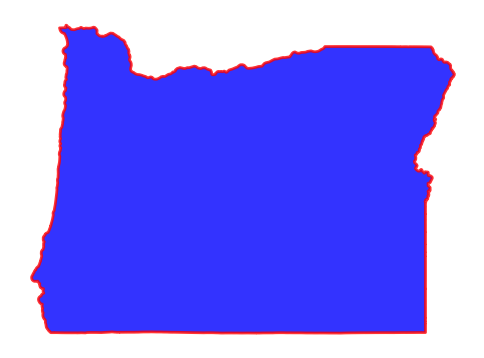

In [2]:
start = "1985-01-01"
end = "2015-01-01"
oregon = gh.helpers.get_us_states("OR")

_, ax = plt.subplots(dpi=100, figsize=(6, 6))
oregon.plot(ax=ax, facecolor="b", edgecolor="r", linewidth=2, alpha=0.8, figsize=(10, 10))
ax.set_axis_off()


In [3]:
nwis = NWIS()
query = {
    "stateCd": "OR",
    "startDt": start,
    "endDt": end,
    "outputDataTypeCd": "dv",  # daily values
    "hasDataTypeCd": "dv",  # daily values
    "parameterCd": "00060",  # discharge
}
sites = nwis.get_info(query)
sites.shape[0]

1919

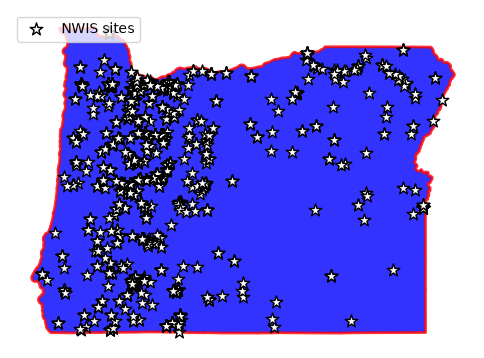

In [4]:
_, ax = plt.subplots(dpi=100, figsize=(6, 6))
oregon.plot(ax=ax, facecolor="b", edgecolor="r", linewidth=2, alpha=0.8, figsize=(10, 10))
sites.plot(ax=ax, marker="*", markersize=90, color="w", edgecolor="k", label="NWIS sites")
ax.legend(loc="upper left")
ax.set_axis_off()

### Bring in dams too

In [5]:
nid = NID()
nid.valid_fields[nid.valid_fields.str.contains("year", case=False)]

55                yearCompleted
56              yearCompletedId
57                yearsModified
176        hydroApprovedIdfYear
181    hydroOrigIdfApprovedYear
186        hydroPmfApprovedYear
192           hydroOtAepDevYear
198            hydroTopInfoYear
257     dsoPiExtensionTenYearId
Name: name, dtype: str

In [6]:
nid.valid_fields[nid.valid_fields.str.contains("state", case=False)]

16                stateFedId
19                     state
21               countyState
27          stateRegulatedId
29     stateRegulatoryAgency
91                 cityState
250                 stateKey
Name: name, dtype: str

In [7]:
dam_list = nid.get_byfilter(
    [
        {
            "stateKey": ["OR"],
            "yearCompleted": ["[1995 2005]"],
        },
    ],
)
dams = dam_list[0]

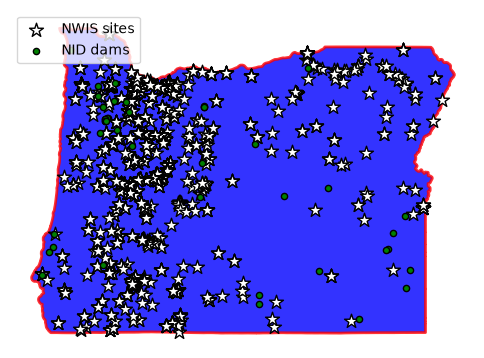

In [8]:
_, ax = plt.subplots(dpi=100, figsize=(6, 6))
oregon.plot(ax=ax, facecolor="b", edgecolor="r", linewidth=2, alpha=0.8, figsize=(10, 10))
sites.plot(ax=ax, marker="*", markersize=110, color="w", edgecolor="k", label="NWIS sites")
dams.plot(ax=ax, marker="o", markersize=20, color="g", edgecolor="k", label="NID dams")
ax.legend(loc="upper left")
ax.set_axis_off()

### Pull in HUCs and mainstems using [geoconnex](https://geoconnex.internetofwater.dev/) from the [Internet of Water](https://internetofwater.org/)

In [40]:
gcx = GeoConnex(dev=False)
print("\n".join(f"{n}: {e.description}" for n, e in gcx.endpoints.items()))

hu02: Two-digit Hydrologic Regions from USGS NHDPlus High Resolution
hu04: Four-digit Hydrologic Subregion from USGS NHDPlus High Resolution
hu06: Six-digit Hydrologic Basins from USGS NHDPlus High Resolution
hu08: Eight-digit Hydrologic Subbasins from USGS NHDPlus High Resolution
hu10: Ten-digit Watersheds from USGS NHDPlus High Resolution
hu12: Twelve-digit Subwatershed from USGS Water Boundary Dataset (WBD)
nat_aq: National Aquifers of the United States from USGS National Water Information System National Aquifer code list
principal_aq: Principal Aquifers of the United States from 2003 USGS data release
sec_hydrg_reg: Secondary Hydrogeologic Regions of the Conterminous United States from 2018 USGS data release
gages: United States Community Contributed Reference Stream Gages
mainstems: United States Community Contributed Reference Mainstem Rivers
mainstems_v3: United States Community Contributed Reference Mainstem Rivers
dams: United States Community Contributed Reference Dams
pws: 

In [41]:
gcx.item = "hu08"
gcx

Item: 'hu08'
Description: Eight-digit Hydrologic Subbasins from USGS NHDPlus High Resolution
Queryable Fields: fid, uri, name, gnis_url, gnis_id, huc8, loaddate
Extent: (-170, 15, -51, 72)

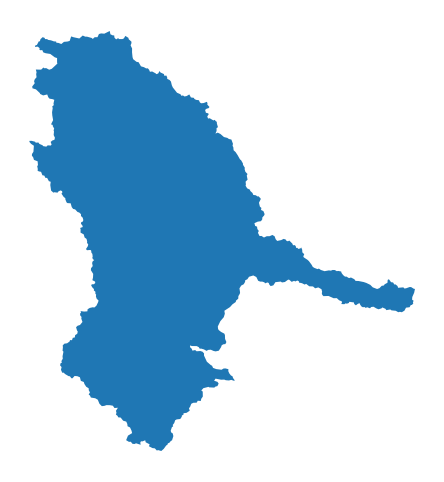

In [42]:
MarysHUC8 = gcx.byid("huc8","17090003")
ax = MarysRiver.plot(figsize=(6, 6))
ax.set_axis_off()

### Using this HUC 08 geometry we can gather the mainstems that are within the Mary's River Basin

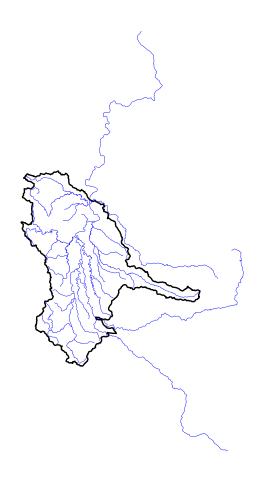

In [43]:
gcx.item = "mainstems"
ms = gcx.bygeometry(MarysRiver.to_crs(4326).union_all(), predicate="intersects")
ax = MarysRiver.plot(figsize=(6, 6), facecolor="none", edgecolor="k")
ms.plot(ax=ax, color="b", lw=0.3)
ax.set_axis_off()

### Get River mainstem by name

<Axes: >

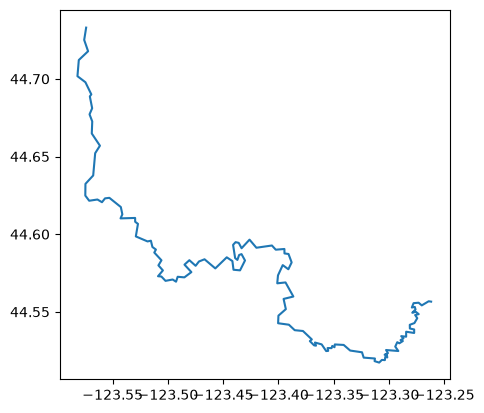

In [28]:
bbox_tuple = (-123.6, 44.4, -123.2, 44.7)
rivers_in_area = gcx.bybox(bbox_tuple)

# Filter the resulting GeoDataFrame locally
marys_river_gdf = rivers_in_area[rivers_in_area["name_at_outlet"] == "Marys River"]
marys_river_gdf.plot()

### Clip the points and rivers to the bounding box of Mary's River HUC 8

In [45]:
sites = sites.to_crs(MarysHUC8.crs)
dams = dams.to_crs(MarysHUC8.crs)
ms = ms.to_crs(MarysHUC8.crs)
clipped_sites= gpd.clip(sites, MarysHUC8)
clipped_dams= gpd.clip(dams, MarysHUC8)
clipped_rivers = gpd.clip(ms, MarysHUC8)

In [46]:
clipped_rivers.to_file(r'C:\Users\mwebe\OneDrive\UW Program\GISPR\Marys.gpkg', layer="MarysRiver", driver="GPKG")
# MarysHUC8.to_file(r'C:\Users\mwebe\OneDrive\UW Program\GISPR\Marys.gpkg', layer="MarysHUC8", driver="GPKG")
clipped_dams.to_file(r'C:\Users\mwebe\OneDrive\UW Program\GISPR\Marys.gpkg', layer="MarysRiverNWIS", driver="GPKG")
clipped_sites.to_file(r'C:\Users\mwebe\OneDrive\UW Program\GISPR\Marys.gpkg', layer="MarysRiverDams", driver="GPKG")